# Review signals and seller history

Two things this notebook sets up for the models. Lateness sits with a small
group of sellers, which makes seller history worth using as a feature. And most
bad reviews are not about delivery at all. Notebook 04 reads those from the text.

## 1. Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

In [2]:
clean = pd.read_parquet("../data/clean/clean.parquet")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")

print("clean: ", clean.shape)
print("reviews: ", reviews.shape)

clean:  (96470, 37)
reviews:  (99224, 7)


In [3]:
reviews['review_score'].value_counts()

review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

In [4]:
print("Unique: ", reviews['order_id'].nunique())

Unique:  98673


In [5]:
main_review = (reviews
               .sort_values(['review_creation_date'], ascending=False)
               .drop_duplicates('order_id'))

print("Cleaned reviews",main_review.shape)

Cleaned reviews (98673, 7)


In [6]:
df = clean.merge(
    main_review[['order_id', 'review_score', 'review_creation_date',
                 'review_comment_message']],
    on='order_id', how='inner')
print("Length before merge: ", len(clean))
print("Length after merge: ", len(df))

Length before merge:  96470
Length after merge:  95824


646 delivered orders have no review, 0.7% of the total.

In [7]:
df['days_late'] = df['delivery_days'] - df['estimated_days']

days_late is the gap between actual and promised delivery. Positive means the order
arrived after the promised date, negative means it came early.

## 2. Delivery delay & review score

In [8]:
print(df.groupby('is_late')['review_score'].agg(['mean', 'count']).round(2))

         mean  count
is_late             
0        4.29  89443
1        2.27   6381


Late orders average 2.27 against 4.29 for on-time ones. A broken promise costs roughly
two stars. Only 6,381 orders out of 95,824 arrive late, but each one lands near the
bottom of the scale.

In [9]:
df['late_bin'] = pd.cut(df['days_late'], bins=[-200, -14, -7, -3, 0, 3, 7, 14, 200])

In [10]:
by_bin = df.groupby('late_bin', observed=True)['review_score'].agg(['mean', 'count']).round(2).reset_index()
print(by_bin)

      late_bin  mean  count
0  (-200, -14]  4.32  41861
1    (-14, -7]  4.30  33883
2     (-7, -3]  4.19   9429
3      (-3, 0]  4.11   4270
4       (0, 3]  3.29   1852
5       (3, 7]  2.10   1748
6      (7, 14]  1.67   1446
7    (14, 200]  1.72   1335


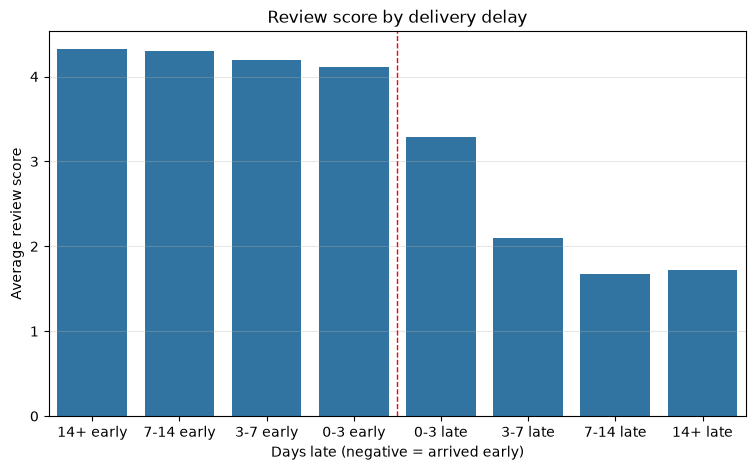

In [11]:
plt.figure(figsize=(9, 5))
sns.barplot(data=by_bin, x='late_bin', y='mean')
plt.axvline(3.5, color='red', linestyle='--', linewidth=1)
plt.title('Review score by delivery delay')
plt.xlabel('Days late (negative = arrived early)')
plt.ylabel('Average review score')
labels = ['14+ early', '7-14 early', '3-7 early', '0-3 early',
          '0-3 late', '3-7 late', '7-14 late', '14+ late']
plt.xticks(range(8), labels)
plt.savefig('../images/score_by_delay.png')
plt.show()

Arriving early buys nothing. Scores hold at 4.1 to 4.3 whether the order came one day
ahead or two weeks ahead.

Crossing the promised date is what hurts. One to three days late drops the score from
4.11 to 3.29. Beyond a week it bottoms out near 1.7 and stops falling.

The penalty is one-sided. Notebook 03 builds its per-state margin around that.

In [12]:
low = df[df['review_score'] <= 2]

In [13]:
print("Late among all orders:", df['is_late'].mean().round(3))
print("Late among 1-2 star orders:", low['is_late'].mean().round(3))

Late among all orders: 0.067
Late among 1-2 star orders: 0.325


Late orders are 6.7% of all deliveries but 32.5% of 1-2 star reviews. A customer who
gets a late parcel is about five times more likely to leave a bad rating.

The other two thirds have nothing to do with delivery time. The structured tables say nothing about them. The review text does.
Notebook 04 reads it.

## 3. Lateness concentration

### Sellers

In [14]:
state_late = df.groupby('customer_state')['is_late'].mean()
df['expected_late'] = df['customer_state'].map(state_late)

worst_sellers = (df.groupby('seller_id')
                 .agg(orders=('order_id', 'count'),
                      late_rate=('is_late', 'mean'),
                      expected=('expected_late', 'mean'),
                      avg_score=('review_score', 'mean'))
                 .query('orders >= 50'))

worst_sellers['excess'] = worst_sellers['late_rate'] - worst_sellers['expected']

print(worst_sellers.sort_values('excess', ascending=False).head(10).round(3).to_string())

                                  orders  late_rate  expected  avg_score  excess
seller_id                                                                       
54965bbe3e4f07ae045b90b0b8541f52      69      0.290     0.063      3.145   0.227
beadbee30901a7f61d031b6b686095ad      63      0.238     0.069      3.937   0.169
a49928bcdf77c55c6d6e05e09a9b4ca5      96      0.219     0.068      3.031   0.151
d20b021d3efdf267a402c402a48ea64b      73      0.192     0.062      3.849   0.129
712e6ed8aa4aa1fa65dab41fed5737e4      76      0.197     0.077      3.395   0.121
88460e8ebdecbfecb5f9601833981930     231      0.177     0.060      3.481   0.117
06a2c3af7b3aee5d69171b0e14f0ee87     384      0.185     0.076      4.018   0.109
cac4c8e7b1ca6252d8f20b2fc1a2e4af      70      0.171     0.065      3.629   0.106
1ca7077d890b907f89be8c954a02686a     107      0.168     0.065      2.393   0.104
6039e27294dc75811c0d8a39069f52c0      63      0.175     0.072      3.730   0.103


Late rate on its own mixes two things, how the seller works and where the parcel goes.
Comparing each seller against the average late rate on their own destinations separates them.

It does not change much. The worst sellers ship to ordinary routes, expected 0.06 to 0.08,
and still run 17% to 29% late. Geography does not explain them.

Score does not follow late rate either: one seller is 24% late and averages
3.94, another is 17% late and sits at 2.39. Delivery explains only part of the score.

In [15]:
by_seller = (df.groupby('seller_id')
                 .agg(orders = ('order_id', 'count'),
                      late_orders = ('is_late', 'sum'),
                      late_rate = ('is_late', 'mean'),
                      avg_score = ('review_score', 'mean')))


print("Total sellers: ", len(by_seller))

Total sellers:  2954


In [16]:
total_late = df['is_late'].sum()
top_50 = by_seller.sort_values('late_orders', ascending=False).head(50)['late_orders']

print("Late orders total:", total_late)
print("From top 50 sellers:", top_50.sum())
print("Share:", round(top_50.sum() / total_late * 100, 2), "%")

print("Worst single seller:", by_seller['late_orders'].max())

Late orders total: 6381
From top 50 sellers: 2441
Share: 38.25 %
Worst single seller: 168


50 sellers out of 2,954 account for 2,441 late orders out of 6,381. That is 1.7% of sellers
producing 38% of all late deliveries. The worst single seller is responsible for 168.

This list ranks by volume of late orders, not by rate. Some of them are simply large.

That is the case for a seller feature. seller_id itself is useless at 2,954
levels. Past late rate is one number and it predicts. It comes from the target,
so notebook 03 has to build it on the training window only.

### Categories

In [17]:
by_category = (df.groupby('product_category_name')
               .agg(orders = ('order_id', 'count'),
                    late_rate = ('is_late', 'mean'),
                    avg_score = ('review_score', 'mean'))
               .query('orders>500')
               .sort_values('late_rate', ascending=False))

print(by_category.round(3).to_string())

                                   orders  late_rate  avg_score
product_category_name                                          
moveis_escritorio                    1241      0.080      3.646
bebes                                2739      0.080      4.121
eletronicos                          2483      0.077      4.129
instrumentos_musicais                 602      0.076      4.243
beleza_saude                         8567      0.074      4.233
cama_mesa_banho                      9090      0.073      4.007
relogios_presentes                   5436      0.073      4.123
automotivo                           3774      0.072      4.153
construcao_ferramentas_construcao     719      0.072      4.152
moveis_decoracao                     6142      0.071      4.078
unknown                              1349      0.071      4.038
telefonia                            4049      0.071      4.059
papelaria                            2231      0.065      4.307
perfumaria                           305

Category barely matters. Late rate runs from 4.2% to 8.0% across categories with real
volume, and average score sits between 4.0 and 4.4 almost everywhere. Office furniture is
the only outlier at 3.65.

Among sellers with 50+ orders, late rate runs from zero to 29%. The seller matters, the product category does not.

### Time

In [18]:
df['purchase_ym'] = df['order_purchase_timestamp'].dt.to_period('M')

In [19]:
by_month = (df.groupby('purchase_ym')
            .agg(orders = ('order_id', 'count'),
                 late_rate = ('is_late', 'mean'),
                 avg_score = ('review_score', 'mean')))

print(by_month)

             orders  late_rate  avg_score
purchase_ym                              
2016-09           1   1.000000   1.000000
2016-10         262   0.007634   4.011450
2016-12           1   0.000000   5.000000
2017-01         741   0.028340   4.198381
2017-02        1643   0.025563   4.203287
2017-03        2527   0.044717   4.187970
2017-04        2290   0.064192   4.136681
2017-05        3517   0.028149   4.235712
2017-06        3111   0.029572   4.222437
2017-07        3842   0.027330   4.257939
2017-08        4165   0.029052   4.312845
2017-09        4118   0.042982   4.267606
2017-10        4446   0.040261   4.204903
2017-11        7237   0.122565   3.987840
2017-12        5461   0.073430   4.088445
2018-01        7013   0.056467   4.109083
2018-02        6507   0.140157   3.880590
2018-03        6948   0.186528   3.812464
2018-04        6752   0.043987   4.206457
2018-05        6722   0.065010   4.236537
2018-06        6072   0.011693   4.307312
2018-07        6118   0.032690   4

Late rate is not stable. It sits around 0.03 for most months, then jumps to 0.12 in
November 2017 and to 0.14 and 0.19 in February and March 2018. Average score drops at
the same time, down to 3.81 in the worst month.

November had more orders than usual, 7,237 against 4,446 the month before. The same
network handles a normal month fine and breaks under load. Black Friday is the likely
reason for that volume.

The first and last rows of 2016 have one order each and are ignored.

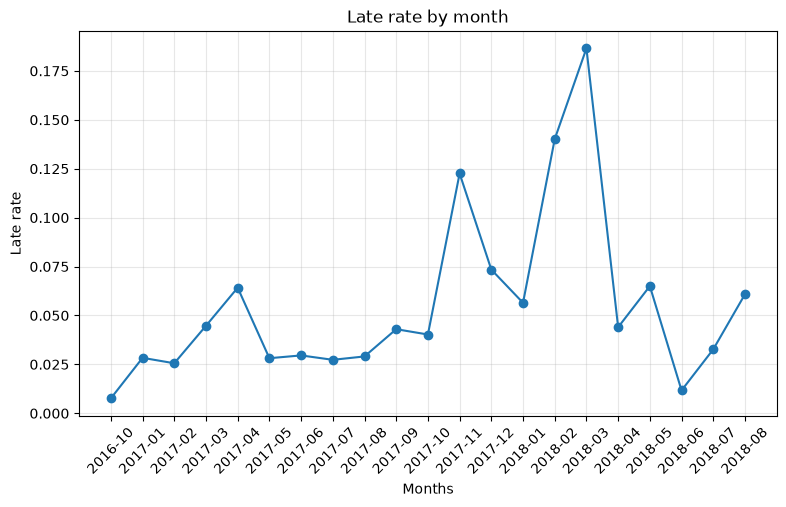

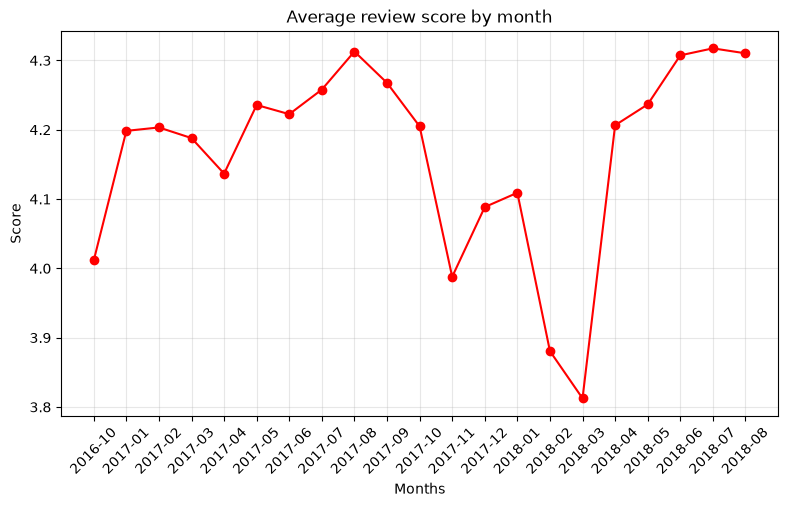

In [20]:
by_month_plot = by_month[by_month['orders'] >= 100].reset_index()
by_month_plot['purchase_ym'] = by_month_plot['purchase_ym'].astype(str)

plt.figure(figsize=(9,5))
plt.plot(by_month_plot['purchase_ym'], by_month_plot['late_rate'], marker='o')
plt.title('Late rate by month')
plt.ylabel('Late rate')
plt.xlabel('Months')
plt.xticks(rotation = 45)
plt.savefig('../images/late_rate_by_month.png')
plt.show()

plt.figure(figsize=(9.25,5))
plt.plot(by_month_plot['purchase_ym'], by_month_plot['avg_score'], marker = 'o', color='red')
plt.title('Average review score by month')
plt.ylabel('Score')
plt.xlabel('Months')
plt.xticks(rotation=45)
plt.savefig('../images/score_by_month.png')
plt.show()

## Findings

1. A late order averages **2.27** stars. An on-time one averages **4.29**.

2. Arriving early buys nothing. Scores hold at **4.1 to 4.3** whether the parcel came a day
   ahead or two weeks ahead. The drop starts once the promised date passes and bottoms out
   at **1.7** after a week.

3. Late orders are **6.7%** of all deliveries and **32.5%** of 1-2 star reviews.

4. **50 sellers out of 2,954** produce **38%** of all late deliveries.

5. Category barely moves the number. Late rate spikes in November, February and March.

## Implications for modelling

1. Seller past late rate. Candidate feature for notebook 03, training window only.

2. Product category is weak. Notebook 03 ranks it low too.

3. Two thirds of bad reviews stay unexplained here. Notebook 04 takes them.